# EDA

## Sales Performance Analysis

In [1]:
## Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## Load the dataset
df = pd.read_csv("../data/processed/cleaned_superstore.csv", encoding='latin-1')

## Display first five observation
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### How is overall business performing?

#### Total Sales

In [3]:
print(df["Sales"].sum())

2297200.8603


#### Total Profit

In [4]:
print(df["Profit"].sum())

286397.0217


#### Monthly Sales Trend

In [5]:
# 1. Convert the column to datetime first
# Use errors='coerce' to turn any non-date junk (like headers) into NaT
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# 2. Now you can use the .dt accessor
df['order-month'] = df['Order Date'].dt.month

df['order-month']


0       11
1       11
2        6
3       10
4       10
        ..
9989     1
9990     2
9991     2
9992     2
9993     5
Name: order-month, Length: 9994, dtype: int32

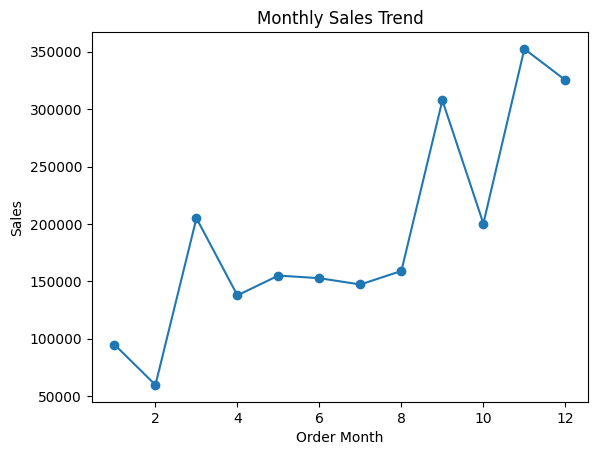

In [6]:
monthly_sales = df.groupby('order-month')["Sales"].sum()

monthly_sales.plot(kind="line", marker='o')

plt.xlabel("Order Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Trend")
plt.show()

#### Business Insight:
Sales peak during certain months, indicating seasonality in customer demand.

## Regional Analysis

### Which regions generate maximum revenue and profit?

#### Region-wise Sales

In [7]:
region_sales = df.groupby("Region")["Sales"].sum()
region_sales

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

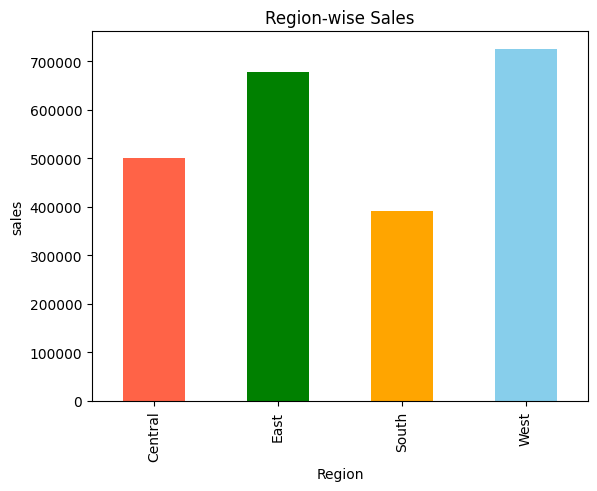

In [8]:
region_sales.plot(kind="bar", color=['tomato', 'green', 'orange', 'skyblue'])
plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("sales")
plt.show()

### Region-wise Profit

In [9]:
region_profit = df.groupby("Region")["Profit"].sum()
region_profit

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

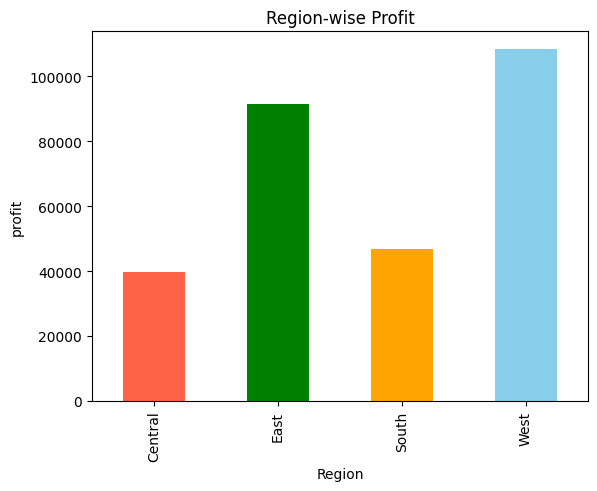

In [10]:
region_profit.plot(kind="bar", color=['tomato', 'green', 'orange', 'skyblue'])
plt.title("Region-wise Profit")
plt.xlabel("Region")
plt.ylabel("profit")
plt.show()

#### Business Insight:
West region contributes highest sales and profitability.

## Product Analysis

### Which products/categories perform best?

#### Category-wise Sales

In [11]:
category_sales = df.groupby("Category")["Sales"].sum()
category_sales

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

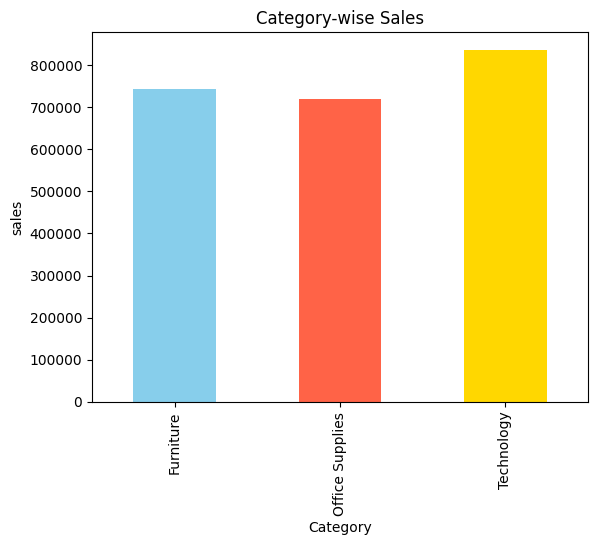

In [12]:
category_sales.plot(kind="bar", color=['skyblue', 'tomato', 'gold',])
plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("sales")
plt.show()

#### Sub-category Profitability

In [13]:
subcategory_profit = df.groupby("Sub-Category")["Profit"].sum()
subcategory_profit

Sub-Category
Accessories    41936.6357
Appliances     18138.0054
Art             6527.7870
Binders        30221.7633
Bookcases      -3472.5560
Chairs         26590.1663
Copiers        55617.8249
Envelopes       6964.1767
Fasteners        949.5182
Furnishings    13059.1436
Labels          5546.2540
Machines        3384.7569
Paper          34053.5693
Phones         44515.7306
Storage        21278.8264
Supplies       -1189.0995
Tables        -17725.4811
Name: Profit, dtype: float64

#### subcategory_profit

In [14]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

#### Business Insight:
Technology products drive the highest revenue contribution.

## Customer Segment Analysis

### Which customer segment is most valuable?

#### Segment-wise Sales

In [15]:
segment_sales = df.groupby("Segment")["Sales"].sum()
segment_sales

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

#### Segment-wise Profit

In [16]:
segment_profit = df.groupby("Segment")["Profit"].sum().to_frame().reset_index()
segment_profit

,Segment,Profit
0,Consumer,134119.2092
1,Corporate,91979.1340
2,Home Office,60298.6785


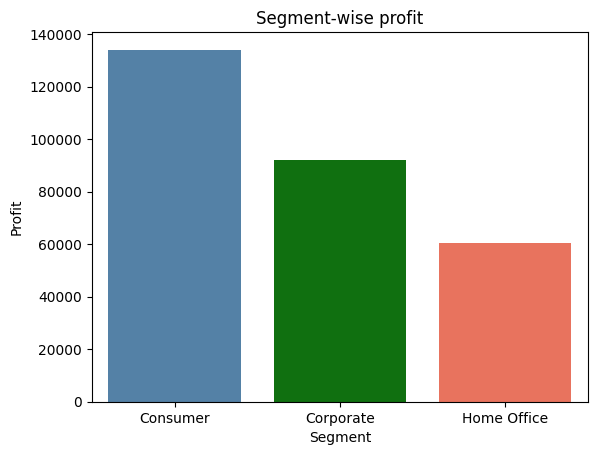

In [17]:
colors = ['steelblue', 'green', 'tomato']
sns.barplot(data=segment_profit, x='Segment', y='Profit', hue='Segment', palette=colors)
plt.title("Segment-wise profit");


#### Business Insight:
Consumer segment contributes the highest overall sales volume.

## Discount Analysis

### How do discounts affect sales and profit?

#### Scatter Plot

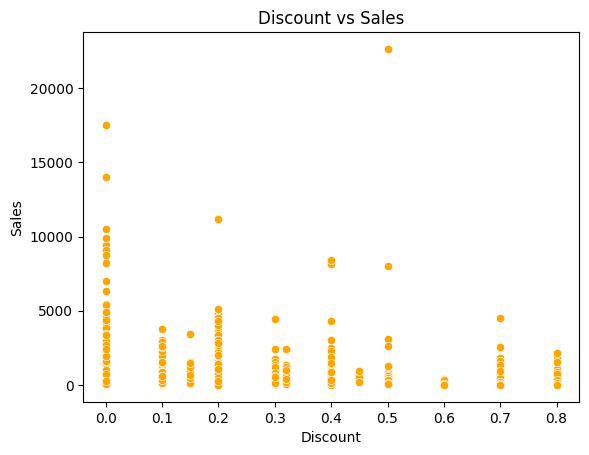

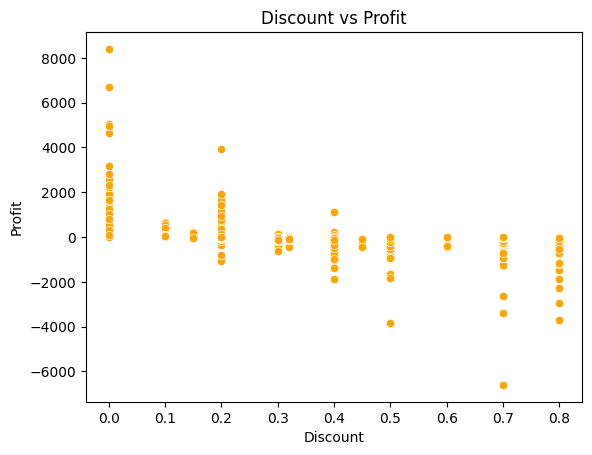

In [19]:
sns.scatterplot(x=df["Discount"], y=df["Sales"], color='orange')
plt.title("Discount vs Sales")
plt.show()

sns.scatterplot(x=df["Discount"], y=df["Profit"], color='orange')
plt.title("Discount vs Profit")
plt.show()

#### Business Insight 

Higher discounts are associated with reduced profitability.

## Shipping Analysis

### Does shipping mode impact sales?

#### Ship Mode Analysis

In [21]:
ship_sales = df.groupby("Ship Mode")["Sales"].sum()
ship_sales

Ship Mode
First Class       3.514284e+05
Same Day          1.283631e+05
Second Class      4.591936e+05
Standard Class    1.358216e+06
Name: Sales, dtype: float64

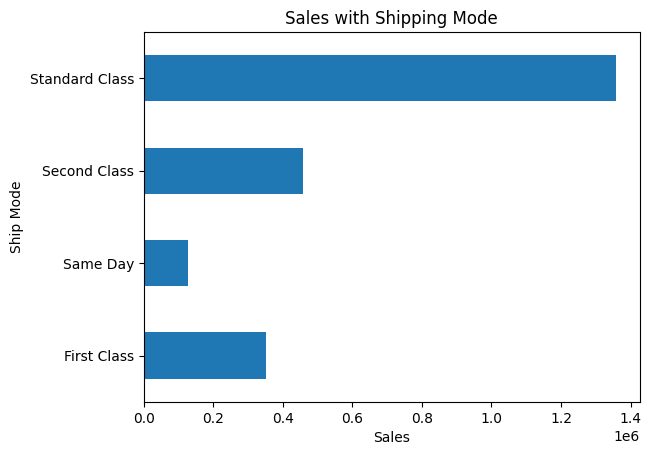

In [23]:
ship_sales.plot(kind="barh")
plt.xlabel("Sales")
plt.title("Sales with Shipping Mode")
plt.show()

## Correlation Analysis

In [21]:
corr = df[["Sales", "Profit", "Quantity", "Discount"]].corr()
corr

,Sales,Profit,Quantity,Discount
Sales,1.000000,0.479064,0.200795,-0.028190
Profit,0.479064,1.000000,0.066253,-0.219487
Quantity,0.200795,0.066253,1.000000,0.008623
Discount,-0.028190,-0.219487,0.008623,1.000000


#### Heatmap

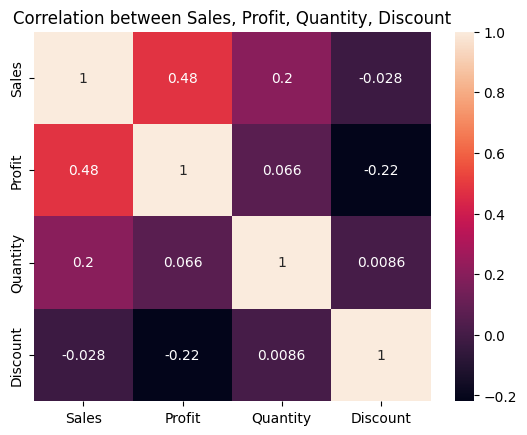

In [23]:
sns.heatmap(corr, annot=True)
plt.title("Correlation between Sales, Profit, Quantity, Discount")
plt.show()

## Forecasting Preparation
#### Time Series Aggregation

In [25]:
sales_timeseries = df.groupby("Order Date")["Sales"].sum()
sales_timeseries

Order Date
2014-01-03      16.4480
2014-01-04     288.0600
2014-01-05      19.5360
2014-01-06    4407.1000
2014-01-07      87.1580
                ...    
2017-12-26     814.5940
2017-12-27     177.6360
2017-12-28    1657.3508
2017-12-29    2915.5340
2017-12-30     713.7900
Name: Sales, Length: 1237, dtype: float64

#### Trend Visualization

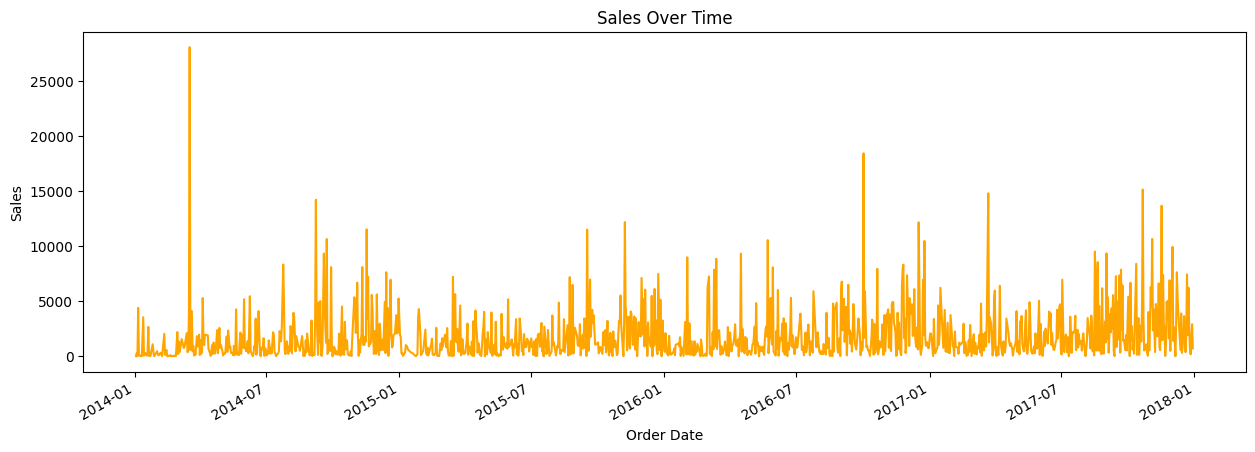

In [28]:
sales_timeseries.plot(figsize=(15,5), color=['orange'])
plt.title("Sales Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.show()